In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "4"

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionXLPipeline
from textboost.text_encoders.clip import TextModelWithProjection
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist

from textboost.ti_utils import load_new_token

torch.set_grad_enabled(False)

In [ ]:
checkpoint_path = "../output/tb-sdxlbase-0829_ti2/backpack"

text_encoder_2 = TextModelWithProjection.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    subfolder="text_encoder_2",
)
text_encoder_2.load_adapter(
    os.path.join(checkpoint_path, "text_encoder_2"),
)
text_encoder_2.set_adapter_mask()
text_encoder_2.replace_lora_forward()


pipeline = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    text_encoder_2=text_encoder_2,
)

# Load learned embeddings
emb_dict = torch.load(os.path.join(checkpoint_path, "learned_embeds_2.bin"))
for key, value in emb_dict.items():
    identifier = load_new_token(
        text_encoder_2,
        pipeline.tokenizer_2,
        placeholder_token=key,
        learned_embedding=value,
    )

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.11it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [5]:
tokenizer = pipeline.tokenizer_2
text_encoder = pipeline.text_encoder_2.to("cuda", dtype=torch.float16)
print(tokenizer)

CLIPTokenizer(name_or_path='/home/kunkim/.cache/huggingface/hub/models--stabilityai--stable-diffusion-xl-base-1.0/snapshots/462165984030d82259a11f4367a4eed129e94a7b/tokenizer_2', vocab_size=49408, model_max_length=77, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '!'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("!", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49408: AddedToken("<backpack>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
}
)


tensor([[1.9648, 0.6113, 0.5659, 0.5952, 0.6216, 0.6948],
        [1.9648, 0.6113, 0.5659, 0.5952, 0.6172, 0.6948],
        [1.9648, 0.6113, 0.5659, 0.5952, 0.6069, 0.6948],
        [1.9648, 0.6113, 0.5659, 0.5952, 0.6128, 0.6948],
        [1.9648, 0.6113, 0.5659, 0.5952, 0.6187, 0.6948],
        [1.9648, 0.6113, 0.5659, 0.5952, 0.6226, 0.6948]], device='cuda:0',
       dtype=torch.float16)
tensor([[72.1250,  6.1992,  4.8945,  5.1094,  6.3828,  4.2500],
        [72.1250,  6.1992,  4.8945,  5.1094,  5.9336,  4.1719],
        [72.1250,  6.1992,  4.8945,  5.1094,  5.8711,  4.3164],
        [72.1250,  6.1992,  4.8945,  5.1094,  6.5938,  4.2500],
        [72.1250,  6.1992,  4.8945,  5.1094,  5.3438,  4.3164],
        [72.1250,  6.1992,  4.8945,  5.1094,  5.5352,  4.0430]],
       device='cuda:0', dtype=torch.float16)
tensor([[71.7500,  8.4375, 10.5078,  7.4844,  7.0430,  4.6914],
        [71.7500,  8.4375, 10.5078,  7.4844,  7.3711,  4.6406],
        [71.7500,  8.4375, 10.5078,  7.4844,  7.

Text(0.5, 0, 'Token Position')

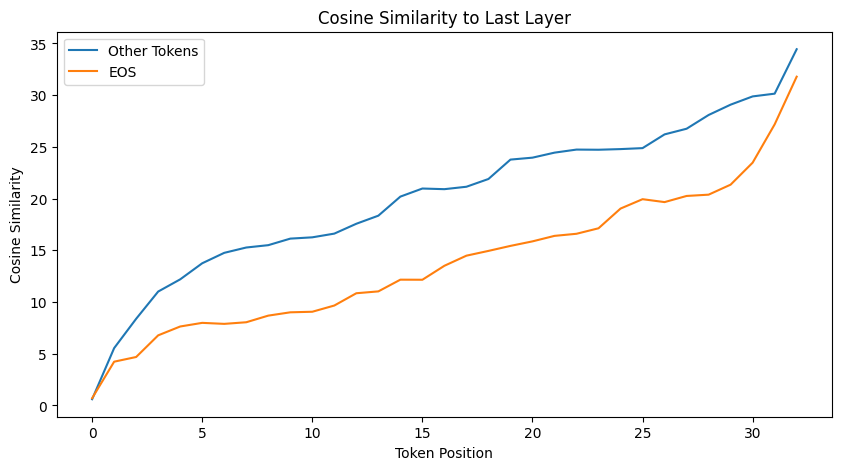

In [10]:
prompt = [
    "photo of a cat",
    "photo of a dog",
    "photo of a wolf",
    "photo of a lion",
    "photo of a desk",
    "photo of a chair",
]
token_ids = tokenizer(
    prompt,
    return_tensors="pt",
    padding=True,
    truncation=True,
).input_ids.to("cuda")
text_features = text_encoder(
    token_ids,
    output_hidden_states=True,
)

sos_norm = []
other_norm = []
eos_norm = []
last_hidden_state = text_features.last_hidden_state
for i, hidden_states in enumerate(text_features.hidden_states):
    norm = hidden_states.norm(dim=-1)
    print(norm)
    sos_norm.append(norm[:, 0].mean().cpu().numpy())
    eos_norm.append(norm[:, -1].mean().cpu().numpy())
    other_norm.append(norm[:, 1:-1].mean(dim=-1).mean().cpu().numpy())

sos_norm = np.array(sos_norm)
other_norm = np.array(other_norm)
eos_norm = np.array(eos_norm)
print(sos_norm.shape, eos_norm.shape, other_norm.shape)
plt.figure(figsize=(10, 5))
# plt.plot(sos_norm.T, label="SOS")
plt.plot(other_norm.T, label="Other Tokens")
plt.plot(eos_norm.T, label="EOS")

plt.legend()
plt.title("Cosine Similarity to Last Layer")
plt.ylabel("Cosine Similarity")
plt.xlabel("Token Position")

tensor([[49406,  1125,   539,   320, 49408, 49407]], device='cuda:0')
tensor([[1.9648, 0.6113, 0.5659, 0.5952, 0.6279, 0.6948]], device='cuda:0',
       dtype=torch.float16)
tensor([[72.1875,  6.2031,  4.8945,  5.1055, 11.0469,  4.0117]],
       device='cuda:0', dtype=torch.float16)
tensor([[71.8125,  8.4375, 10.5078,  7.4844, 76.8125,  4.8281]],
       device='cuda:0', dtype=torch.float16)
tensor([[72.6875, 10.2969, 17.1406,  8.7109, 76.1875,  6.8633]],
       device='cuda:0', dtype=torch.float16)
tensor([[72.6250, 10.9297, 18.8750,  9.2578, 75.8125,  7.6602]],
       device='cuda:0', dtype=torch.float16)
tensor([[72.6875, 12.2578, 19.6406, 12.6641, 75.5000,  7.9805]],
       device='cuda:0', dtype=torch.float16)
tensor([[72.6875, 13.8672, 20.4219, 13.2578, 75.1875,  7.8555]],
       device='cuda:0', dtype=torch.float16)
tensor([[72.6250, 14.3594, 20.6562, 13.4453, 75.0000,  7.8633]],
       device='cuda:0', dtype=torch.float16)
tensor([[72.8750, 14.5625, 20.8281, 13.4844, 74.6250,  8

Text(0.5, 0, 'Token Position')

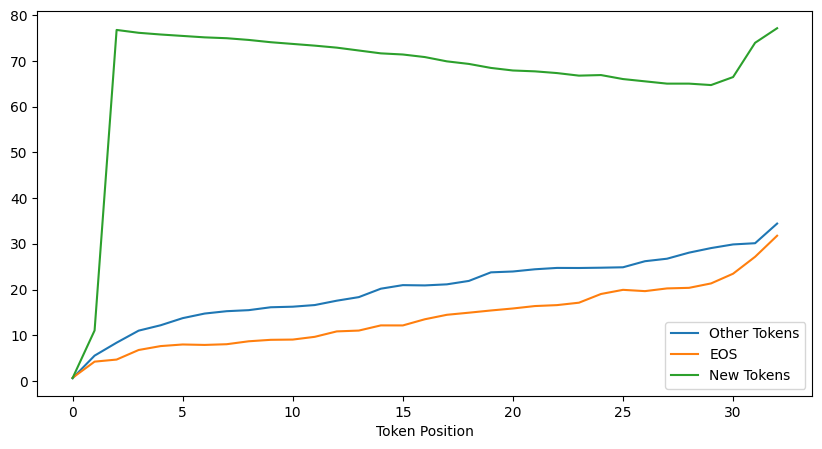

In [11]:
prompt = [
    "photo of a <backpack>",
]

token_ids = tokenizer(
    prompt,
    return_tensors="pt",
    padding=True,
    truncation=True,
).input_ids.to("cuda")
print(token_ids)
text_features = text_encoder(
    token_ids,
    output_hidden_states=True,
)

new_norm = []
last_hidden_state = text_features.last_hidden_state
for i, hidden_states in enumerate(text_features.hidden_states):
    norm = hidden_states.norm(dim=-1)
    print(norm)
    new_norm.append(norm[:, -2].mean(dim=-1).cpu().numpy())

new_norm = np.array(new_norm)
print(sos_norm.shape, eos_norm.shape, new_norm.shape)
plt.figure(figsize=(10, 5))
# plt.plot(sos_norm.T, label="SOS")
plt.plot(other_norm.T, label="Other Tokens")
plt.plot(eos_norm.T, label="EOS")
plt.plot(new_norm.T, label="New Tokens")

plt.legend()
plt.xlabel("Token Position")

In [17]:
import os

from safetensors.torch import load_file

checkpoint_path = "../output/tb-sdxlbase-0829_ti2/backpack"
# checkpoint_path = "../output/tb-sdxlbase-0829-ti/backpack"

ckpt = load_file(
    os.path.join(
        checkpoint_path, "checkpoint-500/text_encoder_2", "adapter_model.safetensors"
    )
)

for k, v in ckpt.items():
    # print(v.norm())
    print(v)

tensor([[-1.8879, -0.6427, -0.0169,  ..., -0.2860, -0.1143,  0.3155]])
tensor([[ 0.0027],
        [ 0.0023],
        [-0.0094],
        ...,
        [ 0.0016],
        [ 0.0045],
        [ 0.0087]])
tensor([[-0.4920, -0.0130,  0.8492,  ...,  0.2679, -1.6393, -0.0118]])
tensor([[ 0.0031],
        [ 0.0025],
        [ 0.0008],
        ...,
        [-0.0067],
        [ 0.0071],
        [ 0.0016]])
tensor([[ 0.8333, -0.6825,  0.8324,  ..., -0.1876, -0.7548,  0.1082]])
tensor([[-0.0024],
        [ 0.0009],
        [ 0.0002],
        ...,
        [-0.0018],
        [-0.0029],
        [ 0.0004]])
tensor([[ 0.7720,  0.5830, -0.4692,  ...,  1.3314, -1.2915,  1.0635]])
tensor([[ 1.2736e-03],
        [-1.3135e-03],
        [ 1.4776e-03],
        ...,
        [ 4.8164e-04],
        [ 2.9647e-03],
        [ 8.9508e-05]])
tensor([[ 0.4710, -0.2792,  0.3213,  ..., -1.7873,  1.0687,  0.0772]])
tensor([[ 3.0548e-03],
        [-2.8757e-03],
        [-2.7773e-04],
        ...,
        [ 1.6597e-03],
    